# Composite Index of Firm-Specific Factors

Starting from the firm-specific factors estimated by the mixed-frequency dynamic
factor model, we build a **composite index** following the steps of the OECD/JRC
*Handbook on Constructing Composite Indicators* (Nardo et al., 2008):

1. **Orientation** — align the direction of each sub-indicator. Here we flip each
   firm factor's sign so it is *negatively* correlated with real output per capita,
   so the composite reads as a firm-side stress/idiosyncratic index that rises when
   output falls.
2. **Normalization** — put the factors on a common scale (z-scores).
3. **Weighting & aggregation** — combine the seven factors. We compare
   **equal weights**, **PCA-based weights**, and **geometric** aggregation.
4. **Robustness / visualization** — compare weighting schemes and validate against
   real output.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

GRAPH_DIR = "../graph"
os.makedirs(GRAPH_DIR, exist_ok=True)

# Firm-specific factors (monthly) from the DFM; real output per capita (quarterly).
factors = pd.read_csv("../data/firm_specific_factors.csv", parse_dates=[0], index_col=0)
y = pd.read_csv("../data/macro_y_pi_i_2015_2026Q2.csv", parse_dates=[0], index_col=0)["y"]
firms = list(factors.columns)
print(factors.shape, firms)
factors.tail()

(136, 7) ['AAPL', 'MSFT', 'AMZN', 'NVDA', 'GOOGL', 'TSLA', 'META']


,AAPL,MSFT,AMZN,NVDA,GOOGL,TSLA,META
date,,,,,,,
2025-12-01,-1.654101,-2.993760,-1.372196,-0.834978,1.767609,-0.856076,0.213372
2026-01-01,-2.133604,-3.501966,-1.268885,-0.821492,2.080330,-1.030860,0.177150
2026-02-01,-1.670544,-4.334565,-1.673532,-0.561365,2.036436,-1.011688,0.267303
2026-03-01,-1.821995,-4.362684,-1.593198,-0.517310,1.680249,-1.083707,-0.021364
2026-04-01,-1.812919,-4.500739,-1.102306,-0.510331,2.192602,-1.294913,0.152622


## Step 1 — Orientation: negative correlation with real output

Factors from a DFM are sign-indeterminate. We flip each firm factor so its
correlation with real output per capita $y$ is negative (comparing at the quarterly
frequency, since $y$ is quarterly).

In [2]:
corr_before = factors.resample("QS").mean().corrwith(y)
signs = np.where(corr_before.values > 0, -1.0, 1.0)   # flip if positively correlated with y
factors_o = factors.mul(signs, axis=1)
corr_after = factors_o.resample("QS").mean().corrwith(y)

pd.DataFrame({"corr_with_y_before": corr_before,
              "sign_flip": signs.astype(int),
              "corr_with_y_after": corr_after}).round(3)

,corr_with_y_before,sign_flip,corr_with_y_after
AAPL,0.020,-1,-0.020
MSFT,0.006,-1,-0.006
AMZN,-0.123,1,-0.123
NVDA,0.035,-1,-0.035
GOOGL,-0.220,1,-0.220
TSLA,-0.032,1,-0.032
META,-0.051,1,-0.051


## Step 2 — Normalization (z-scores)

Each oriented factor is standardized to mean 0 and unit variance, so no single firm
dominates the composite through scale.

In [3]:
Z = (factors_o - factors_o.mean()) / factors_o.std(ddof=0)
Z.describe().loc[["mean", "std", "min", "max"]].round(3)

,AAPL,MSFT,AMZN,NVDA,GOOGL,TSLA,META
mean,0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000
std,1.004,1.004,1.004,1.004,1.004,1.004,1.004
min,-1.991,-1.888,-2.771,-1.812,-2.236,-2.372,-3.957
max,2.396,3.364,1.923,2.322,2.002,2.307,1.505


## Step 3 — Weighting and aggregation

We consider three schemes:

- **Equal weights (linear):** $w_i = 1/N$; the transparent OECD baseline.
- **PCA weights (linear):** weights proportional to the squared loadings of the
  first principal component of the seven factors (data-driven; puts more weight on
  firms that move most with the common component).
- **Equal weights (geometric):** min–max rescale each factor to $[1,100]$ and take
  the geometric mean — a less compensatory aggregation.

In [4]:
# (a) Equal weights
w_equal = pd.Series(1 / len(firms), index=firms)

# (b) PCA-based weights: squared first-PC loadings, normalized to sum to 1.
pca = PCA().fit(Z.values)
load1 = pca.components_[0]
if load1.sum() < 0:
    load1 = -load1
w_pca = pd.Series(load1 ** 2 / (load1 ** 2).sum(), index=firms)

weights = pd.DataFrame({"equal": w_equal, "pca": w_pca})
print("first PC explains %.1f%% of the seven factors' variance"
      % (pca.explained_variance_ratio_[0] * 100))
weights.round(3)

first PC explains 33.3% of the seven factors' variance


,equal,pca
AAPL,0.143,0.283
MSFT,0.143,0.074
AMZN,0.143,0.003
NVDA,0.143,0.185
GOOGL,0.143,0.024
TSLA,0.143,0.234
META,0.143,0.196


In [5]:
# Linear (weighted arithmetic) aggregation
ci_equal = Z.mul(w_equal, axis=1).sum(axis=1)
ci_pca   = Z.mul(w_pca,   axis=1).sum(axis=1)

# Geometric aggregation (equal weights): needs positive inputs -> min-max to [1,100].
mm = 1 + 99 * (factors_o - factors_o.min()) / (factors_o.max() - factors_o.min())
ci_geom = np.exp(np.log(mm).mean(axis=1))

def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

composite = pd.DataFrame({
    "equal_linear":    zscore(ci_equal),
    "pca_linear":      zscore(ci_pca),
    "equal_geometric": zscore(ci_geom),
})
# Headline composite index: equal-weight linear (OECD baseline).
composite["composite_index"] = composite["equal_linear"]
composite.tail()

,equal_linear,pca_linear,equal_geometric,composite_index
date,,,,
2025-12-01,1.977007,1.936062,1.979086,1.977007
2026-01-01,2.482787,2.390806,2.228477,2.482787
2026-02-01,2.361603,2.034854,1.952290,2.361603
2026-03-01,2.159335,1.903076,1.850099,2.159335
2026-04-01,2.602713,1.906219,2.112947,2.602713


## The seven firm-specific factors and the composite index

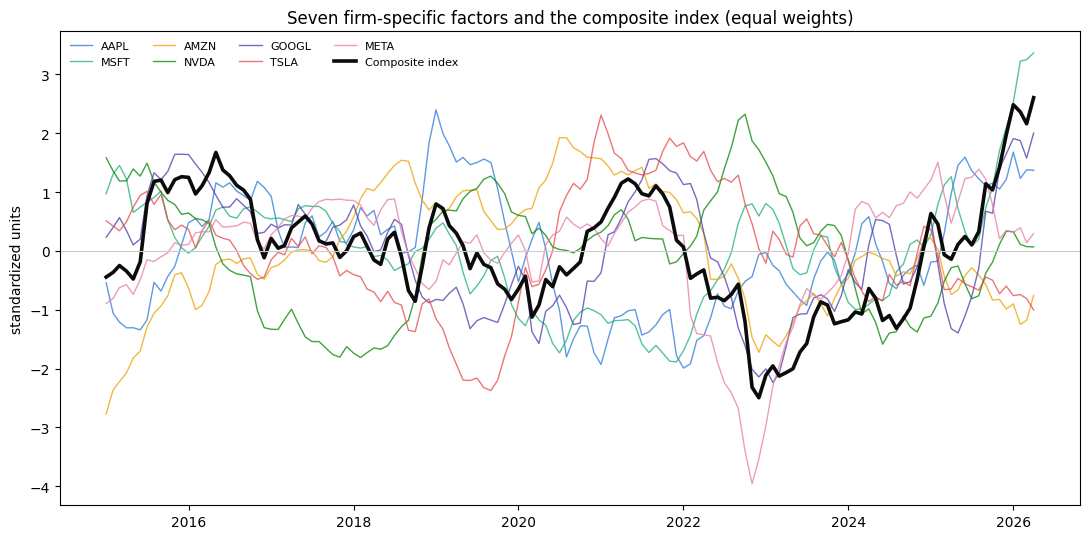

In [6]:
firm_colors = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4"]

fig, ax = plt.subplots(figsize=(11, 5.5))
for f, c in zip(firms, firm_colors):
    ax.plot(Z.index, Z[f], color=c, lw=1.0, alpha=0.75, label=f)
ax.plot(composite.index, composite["composite_index"], color="#0b0b0b", lw=2.6,
        label="Composite index")
ax.axhline(0, color="0.8", lw=0.8)
ax.set_title("Seven firm-specific factors and the composite index (equal weights)")
ax.set_ylabel("standardized units")
ax.set_xlabel("")
ax.legend(ncol=4, fontsize=8, loc="upper left", frameon=False)
plt.tight_layout()
fig.savefig(f"{GRAPH_DIR}/composite_index_firm_factors.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparing weighting / aggregation schemes

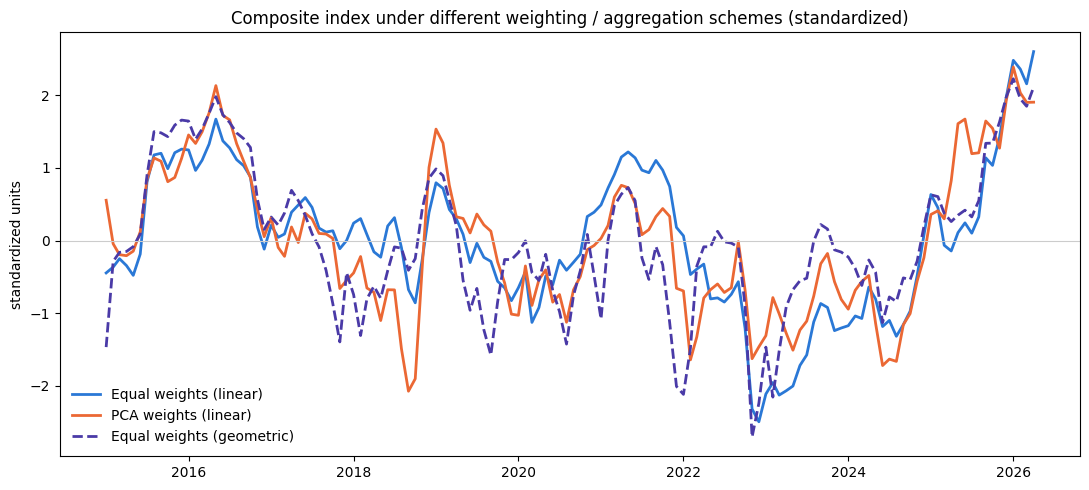

cross-correlation among schemes:


,equal_linear,pca_linear,equal_geometric
equal_linear,1.000,0.842,0.755
pca_linear,0.842,1.000,0.788
equal_geometric,0.755,0.788,1.000


In [7]:
styles = {
    "equal_linear":    ("#2a78d6", "-",  "Equal weights (linear)"),
    "pca_linear":      ("#eb6834", "-",  "PCA weights (linear)"),
    "equal_geometric": ("#4a3aa7", "--", "Equal weights (geometric)"),
}
fig, ax = plt.subplots(figsize=(11, 5))
for col, (c, ls, lab) in styles.items():
    ax.plot(composite.index, composite[col], color=c, ls=ls, lw=2.0, label=lab)
ax.axhline(0, color="0.8", lw=0.8)
ax.set_title("Composite index under different weighting / aggregation schemes (standardized)")
ax.set_ylabel("standardized units")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(f"{GRAPH_DIR}/composite_index_weight_methods.png", dpi=150, bbox_inches="tight")
plt.show()

print("cross-correlation among schemes:")
composite[list(styles)].corr().round(3)

## Weights by method

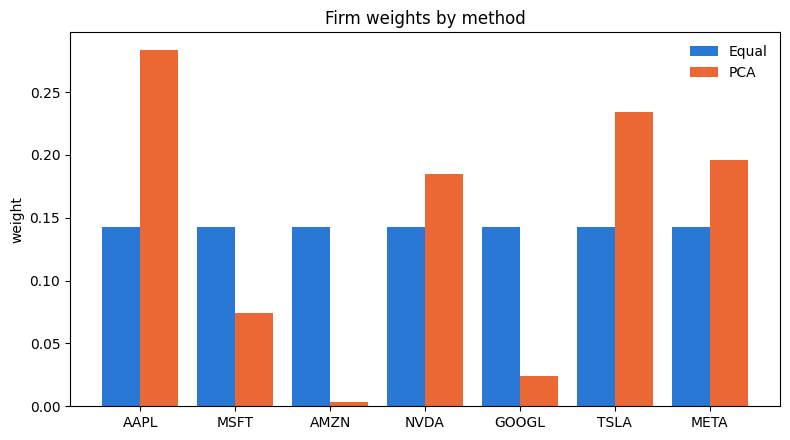

In [8]:
x = np.arange(len(firms)); wd = 0.4
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - wd/2, weights["equal"], wd, label="Equal", color="#2a78d6")
ax.bar(x + wd/2, weights["pca"],   wd, label="PCA",   color="#eb6834")
ax.set_xticks(x, firms)
ax.set_ylabel("weight")
ax.set_title("Firm weights by method")
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(f"{GRAPH_DIR}/composite_index_weights.png", dpi=150, bbox_inches="tight")
plt.show()

## Validation and export

In [9]:
val = composite.resample("QS").mean().corrwith(y)
print("correlation of each composite with real output per capita (quarterly):")
print(val.round(3).to_string())

composite.index.name = "date"
composite.to_csv("../data/composite_index.csv")
print("\nsaved ../data/composite_index.csv", composite.shape)

correlation of each composite with real output per capita (quarterly):
equal_linear      -0.243
pca_linear        -0.137
equal_geometric   -0.152
composite_index   -0.243

saved ../data/composite_index.csv (136, 4)
